<a href="https://colab.research.google.com/github/Farzanehnaderi/Tehran_ENUI_Urban_Monitoring_GEE/blob/main/Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geemap earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.0 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()

ee.Initialize(
    project="bold-physics-478216-b4"
)

print("GEE initialized successfully.")

GEE initialized successfully.


In [ ]:
ENUI_ASSET_ID = "projects/bold-physics-478216-b4/assets/ENUI_Tehran_Province_2020"

ENUI = ee.Image(ENUI_ASSET_ID)

print("ENUI bands:")
print(ENUI.bandNames().getInfo())

ENUI bands:
['ENUI']


In [ ]:
print(ENUI.getInfo()["type"])
print(ENUI)
print(roi)

Image
ee.Image({
  "functionInvocationValue": {
    "functionName": "Image.load",
    "arguments": {
      "id": {
        "constantValue": "projects/bold-physics-478216-b4/assets/ENUI_Tehran_Province_2020"
      }
    }
  }
})


NameError: name 'roi' is not defined

In [ ]:
TEHRAN_ASSET_ID = "projects/bold-physics-478216-b4/assets/Teharn_province"

In [ ]:
tehran = ee.FeatureCollection(TEHRAN_ASSET_ID)

roi = tehran.geometry()

print(roi)

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Collection.geometry",
    "arguments": {
      "collection": {
        "functionInvocationValue": {
          "functionName": "Collection.loadTable",
          "arguments": {
            "tableId": {
              "constantValue": "projects/bold-physics-478216-b4/assets/Teharn_province"
            }
          }
        }
      }
    }
  }
})


In [ ]:
Map_ENUI = geemap.Map()

Map_ENUI.centerObject(roi, 8)

Map_ENUI.addLayer(
    ENUI,
    {
        "min": 0.25,
        "max": 0.75,
        "palette": [
            "#313695",
            "#74add1",
            "#ffffbf",
            "#fdae61",
            "#d73027"
        ]
    },
    "ENUI 2020"
)

Map_ENUI.addLayer(
    roi,
    {"color": "black"},
    "Tehran Province"
)

Map_ENUI.add_layer_control()

Map_ENUI

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
dw_2020 = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .filterBounds(roi)
    .filterDate("2020-01-01", "2021-01-01")
)

print("Number of images:")
print(dw_2020.size().getInfo())

Number of images:
462


In [ ]:
dw_2020 = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .filterBounds(roi)
    .filterDate("2020-01-01", "2021-01-01")
)

print("Number of images:", dw_2020.size().getInfo())

dw_mean = dw_2020.select([
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice"
]).mean().clip(roi)

print("Dynamic World composite created.")

Number of images: 462
Dynamic World composite created.


In [ ]:
# ==========================================
# Dynamic World - Dominant Land Cover Class
# ==========================================

dw_label = (
    dw_2020
    .select("label")
    .mode()
    .clip(roi)
)

# ------------------------------------------
# Dynamic World classes
# ------------------------------------------

dw_palette = [
    "#419BDF",  # 0 - Water
    "#397D49",  # 1 - Trees
    "#88B053",  # 2 - Grass
    "#7A87C6",  # 3 - Flooded vegetation
    "#E49635",  # 4 - Crops
    "#DFC35A",  # 5 - Shrub & scrub
    "#C4281B",  # 6 - Built area
    "#A59B8F",  # 7 - Bare ground
    "#B39FE1"   # 8 - Snow & ice
]

dw_legend = {
    "Water": "#419BDF",
    "Trees": "#397D49",
    "Grass": "#88B053",
    "Flooded vegetation": "#7A87C6",
    "Crops": "#E49635",
    "Shrub & scrub": "#DFC35A",
    "Built area": "#C4281B",
    "Bare ground": "#A59B8F",
    "Snow & ice": "#B39FE1"
}

# ------------------------------------------
# Create map
# ------------------------------------------

Map_DW = geemap.Map()

Map_DW.centerObject(roi, 8)

# Dynamic World
Map_DW.addLayer(
    dw_label,
    {
        "min": 0,
        "max": 8,
        "palette": dw_palette
    },
    "Dynamic World - Dominant Classes"
)

# ------------------------------------------
# Tehran Province boundary
# ------------------------------------------

Map_DW.addLayer(
    tehran.style(
        color="000000",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province Boundary"
)

# ------------------------------------------
# Legend
# ------------------------------------------

Map_DW.add_legend(
    title="Dynamic World Land Cover",
    legend_dict=dw_legend
)

# Layer control
Map_DW.add_layer_control()

Map_DW

Map(center=[35.553695204637926, 51.72714652707816], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# ==========================================
# Dynamic World - Probability Bands
# ==========================================
dw_probability = (
    dw_2020
    .select([
        "water",
        "trees",
        "grass",
        "flooded_vegetation",
        "crops",
        "shrub_and_scrub",
        "built",
        "bare",
        "snow_and_ice"
    ])
    .mean()
    .clip(roi)
)

print("Probability bands:")
print(dw_probability.bandNames().getInfo())

Probability bands:
['water', 'trees', 'grass', 'flooded_vegetation', 'crops', 'shrub_and_scrub', 'built', 'bare', 'snow_and_ice']


In [ ]:
# ==========================================
# Built Probability
# ==========================================

built_probability = dw_probability.select("built")

Map_Built_Prob = geemap.Map()

Map_Built_Prob.centerObject(roi, 8)

Map_Built_Prob.addLayer(
    built_probability,
    {
        "min": 0,
        "max": 1,
        "palette": [
            "white",
            "yellow",
            "orange",
            "red",
            "darkred"
        ]
    },
    "Built Probability"
)

Map_Built_Prob.addLayer(
    tehran.style(
        color="000000",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province Boundary"
)

Map_Built_Prob.add_legend(
    title="Built Probability",
    legend_dict={
        "0 - Very Low": "white",
        "0.25 - Low": "yellow",
        "0.50 - Medium": "orange",
        "0.75 - High": "red",
        "1.00 - Very High": "darkred"
    }
)

Map_Built_Prob.add_layer_control()

Map_Built_Prob

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# ==========================================
# Built Probability Percentiles
# ==========================================

percentiles = built_probability.reduceRegion(
    reducer=ee.Reducer.percentile([
        5, 10, 25, 50, 75, 90, 95
    ]),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

print("Built Probability Percentiles:")
print(percentiles.getInfo())

Built Probability Percentiles:


In [ ]:
# ==========================================
# Built Probability Statistics
# ==========================================

built_stats = built_probability.reduceRegion(
    reducer=ee.Reducer.minMax()
        .combine(
            reducer2=ee.Reducer.mean(),
            sharedInputs=True
        ),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

print("Built Probability Statistics:")
print(built_stats.getInfo())

Built Probability Statistics:
{'built_max': 0.7889855494600182, 'built_mean': 0.12128789846430349, 'built_min': 0.018955135555006563}


In [16]:
# ==========================================
# Dynamic World Urban Threshold Analysis
# ==========================================

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

total_area = roi.area(maxError=1)

print("Threshold Sensitivity Analysis")
print("=" * 70)

for threshold in thresholds:

    urban = built_probability.gte(threshold)

    urban_area = (
        ee.Image.pixelArea()
        .updateMask(urban)
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=10,
            maxPixels=1e13
        )
        .get("area")
    )

    result = ee.Dictionary({
        "threshold": threshold,
        "urban_area_km2": ee.Number(urban_area).divide(1e6),
        "urban_percent": ee.Number(urban_area)
            .divide(total_area)
            .multiply(100)
    })

    print(result.getInfo())

Threshold Sensitivity Analysis
{'threshold': 0.1, 'urban_area_km2': 2421.511316228211, 'urban_percent': 17.677962611514918}
{'threshold': 0.2, 'urban_area_km2': 1916.6117265722341, 'urban_percent': 13.992001695829314}
{'threshold': 0.3, 'urban_area_km2': 1671.312011275682, 'urban_percent': 12.201219564617904}
{'threshold': 0.4, 'urban_area_km2': 1468.5086651216795, 'urban_percent': 10.720677249257237}
{'threshold': 0.5, 'urban_area_km2': 1258.5479374046472, 'urban_percent': 9.187883299629302}
{'threshold': 0.6, 'urban_area_km2': 983.7098854267895, 'urban_percent': 7.181459966182516}


KeyboardInterrupt: 

In [18]:
# ==========================================
# Dynamic World - Urban / Non-Urban
# Initial Threshold = 0.5
# ==========================================

DW_THRESHOLD = 0.5

urban_mask = built_probability.gte(DW_THRESHOLD)

# 1 = Urban
# 0 = Non-Urban
dw_urban_nonurban = urban_mask.rename("Urban")

print("Dynamic World binary classification created.")
print("Threshold:", DW_THRESHOLD)

Dynamic World binary classification created.
Threshold: 0.5


In [19]:
# ==============================
# Dynamic World - Urban / Non-Urban Map
# ==============================

Map_DW_Binary = geemap.Map()

Map_DW_Binary.centerObject(roi, 8)

# Urban = 1
# Non-Urban = 0
Map_DW_Binary.addLayer(
    dw_urban_nonurban,
    {
        "min": 0,
        "max": 1,
        "palette": ["gray", "red"]
    },
    "Urban / Non-Urban"
)

# Tehran Province boundary
Map_DW_Binary.addLayer(
    tehran.style(
        color="000000",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province Boundary"
)

# Legend
binary_legend = {
    "Non-Urban": "gray",
    "Urban": "red"
}

Map_DW_Binary.add_legend(
    title="Dynamic World Classification",
    legend_dict=binary_legend
)

Map_DW_Binary.add_layer_control()

Map_DW_Binary

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [20]:
# ==========================================
# ENUI Validation using Dynamic World
# ==========================================

# ENUI image
enui = ENUI.select("ENUI")

# Dynamic World binary class
# 1 = Urban
# 0 = Non-Urban
dw_class = dw_urban_nonurban.rename("DW_Class")

# Combine ENUI and DW class
validation_image = enui.addBands(dw_class)

print("Validation image created.")
print(validation_image.bandNames().getInfo())

Validation image created.
['ENUI', 'DW_Class']


In [21]:
# ==========================================
# ENUI Statistics by Urban / Non-Urban
# ==========================================

# Urban mask
urban_mask = dw_class.eq(1)

# Non-Urban mask
nonurban_mask = dw_class.eq(0)

# ENUI in Urban areas
enui_urban = enui.updateMask(urban_mask)

urban_stats = enui_urban.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        )
        .combine(
            reducer2=ee.Reducer.minMax(),
            sharedInputs=True
        ),
    geometry=roi,
    scale=500,
    maxPixels=1e9
)

# ENUI in Non-Urban areas
enui_nonurban = enui.updateMask(nonurban_mask)

nonurban_stats = enui_nonurban.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        )
        .combine(
            reducer2=ee.Reducer.minMax(),
            sharedInputs=True
        ),
    geometry=roi,
    scale=500,
    maxPixels=1e9
)

print("Urban ENUI statistics:")
print(urban_stats.getInfo())

print("\nNon-Urban ENUI statistics:")
print(nonurban_stats.getInfo())

Urban ENUI statistics:
{'ENUI_max': 0.6809951249146677, 'ENUI_mean': 0.4980245267935219, 'ENUI_min': 0.3937444609601653, 'ENUI_stdDev': 0.03144257287240824}

Non-Urban ENUI statistics:
{'ENUI_max': 0.6730594178130288, 'ENUI_mean': 0.4535396206331965, 'ENUI_min': 0.2641739133911369, 'ENUI_stdDev': 0.01821519644839875}


In [22]:
# ==========================================
# Correlation between ENUI and Built Probability
# ==========================================

correlation_image = ENUI.select("ENUI").addBands(
    built_probability.rename("Built_Probability")
)

correlation = correlation_image.reduceRegion(
    reducer=ee.Reducer.pearsonsCorrelation(),
    geometry=roi,
    scale=500,
    maxPixels=1e9
)

print("Pearson correlation between ENUI and Built Probability:")
print(correlation.getInfo())

Pearson correlation between ENUI and Built Probability:
{'correlation': 0.5474943439692148, 'p-value': 0}


In [23]:
# ==========================================
# Threshold Sensitivity Analysis
# ==========================================

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds:

    # Urban / Non-Urban classification
    urban = built_probability.gte(threshold)
    nonurban = built_probability.lt(threshold)

    # ENUI for Urban
    urban_mean = ENUI.updateMask(urban).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=500,
        maxPixels=1e9
    ).get("ENUI")

    # ENUI for Non-Urban
    nonurban_mean = ENUI.updateMask(nonurban).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=500,
        maxPixels=1e9
    ).get("ENUI")

    results.append({
        "Threshold": threshold,
        "Urban_ENUI_Mean": urban_mean,
        "NonUrban_ENUI_Mean": nonurban_mean
    })

# Evaluate results
results_info = []

for r in results:
    results_info.append({
        "Threshold": r["Threshold"],
        "Urban_ENUI_Mean": ee.Number(r["Urban_ENUI_Mean"]).getInfo(),
        "NonUrban_ENUI_Mean": ee.Number(r["NonUrban_ENUI_Mean"]).getInfo()
    })

for r in results_info:
    difference = r["Urban_ENUI_Mean"] - r["NonUrban_ENUI_Mean"]

    print(
        f"Threshold = {r['Threshold']:.1f} | "
        f"Urban = {r['Urban_ENUI_Mean']:.4f} | "
        f"Non-Urban = {r['NonUrban_ENUI_Mean']:.4f} | "
        f"Difference = {difference:.4f}"
    )

Threshold = 0.1 | Urban = 0.4752 | Non-Urban = 0.4523 | Difference = 0.0229
Threshold = 0.2 | Urban = 0.4824 | Non-Urban = 0.4525 | Difference = 0.0299
Threshold = 0.3 | Urban = 0.4877 | Non-Urban = 0.4527 | Difference = 0.0350
Threshold = 0.4 | Urban = 0.4929 | Non-Urban = 0.4531 | Difference = 0.0398
Threshold = 0.5 | Urban = 0.4980 | Non-Urban = 0.4535 | Difference = 0.0445
Threshold = 0.6 | Urban = 0.5043 | Non-Urban = 0.4542 | Difference = 0.0501
Threshold = 0.7 | Urban = 0.5153 | Non-Urban = 0.4557 | Difference = 0.0596


In [24]:
# ==========================================
# ENUI Validation - Built Probability Bins
# ==========================================

enui = ENUI.select("ENUI")
built_prob = built_probability.rename("Built_Probability")

# تعریف بازه‌های احتمال
bins = [
    (0.0, 0.1),
    (0.1, 0.2),
    (0.2, 0.3),
    (0.3, 0.4),
    (0.4, 0.5),
    (0.5, 0.6),
    (0.6, 0.7),
    (0.7, 0.8),
    (0.8, 0.9),
    (0.9, 1.0)
]

results = []

for lower, upper in bins:

    # پیکسل‌های داخل بازه
    mask = built_prob.gte(lower).And(built_prob.lt(upper))

    # ENUI مربوط به همان پیکسل‌ها
    enui_bin = enui.updateMask(mask)

    stats = enui_bin.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(
                reducer2=ee.Reducer.count(),
                sharedInputs=True
            ),
        geometry=roi,
        scale=500,
        maxPixels=1e9
    )

    results.append(
        ee.Feature(
            None,
            {
                "Probability_Lower": lower,
                "Probability_Upper": upper,
                "ENUI_Mean": stats.get("ENUI_mean"),
                "Pixel_Count": stats.get("ENUI_count")
            }
        )
    )

results_fc = ee.FeatureCollection(results)

print("ENUI by Built Probability bins:")
print(results_fc.getInfo())

ENUI by Built Probability bins:
{'type': 'FeatureCollection', 'columns': {'ENUI_Mean': 'Object', 'Pixel_Count': 'Long', 'Probability_Lower': 'Number', 'Probability_Upper': 'Number', 'system:index': 'String'}, 'features': [{'type': 'Feature', 'geometry': None, 'id': '0', 'properties': {'ENUI_Mean': 0.4523161603816275, 'Pixel_Count': 55407, 'Probability_Lower': 0, 'Probability_Upper': 0.1}}, {'type': 'Feature', 'geometry': None, 'id': '1', 'properties': {'ENUI_Mean': 0.4551880602300878, 'Pixel_Count': 3467, 'Probability_Lower': 0.1, 'Probability_Upper': 0.2}}, {'type': 'Feature', 'geometry': None, 'id': '2', 'properties': {'ENUI_Mean': 0.4603803959828064, 'Pixel_Count': 1875, 'Probability_Lower': 0.2, 'Probability_Upper': 0.3}}, {'type': 'Feature', 'geometry': None, 'id': '3', 'properties': {'ENUI_Mean': 0.4666119390056698, 'Pixel_Count': 1533, 'Probability_Lower': 0.3, 'Probability_Upper': 0.4}}, {'type': 'Feature', 'geometry': None, 'id': '4', 'properties': {'ENUI_Mean': 0.474369587767

In [25]:
# ==========================================
# Final Dynamic World Classification
# Threshold = 0.5
# ==========================================

DW_THRESHOLD = 0.5

urban_mask = built_probability.gte(DW_THRESHOLD)
nonurban_mask = built_probability.lt(DW_THRESHOLD)

dw_final = urban_mask.rename("Urban")

pixel_area = ee.Image.pixelArea()

urban_area = (
    pixel_area
    .updateMask(urban_mask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=500,
        maxPixels=1e13
    )
)

nonurban_area = (
    pixel_area
    .updateMask(nonurban_mask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=500,
        maxPixels=1e13
    )
)

urban_km2 = ee.Number(urban_area.get("area")).divide(1e6)
nonurban_km2 = ee.Number(nonurban_area.get("area")).divide(1e6)

total_km2 = urban_km2.add(nonurban_km2)

urban_percent = urban_km2.divide(total_km2).multiply(100)
nonurban_percent = nonurban_km2.divide(total_km2).multiply(100)

print("====================================")
print("Final Dynamic World Classification")
print("====================================")
print("Threshold:", DW_THRESHOLD)

print("Urban Area (km²):", urban_km2.getInfo())
print("Urban Area (%):", urban_percent.getInfo())

print("Non-Urban Area (km²):", nonurban_km2.getInfo())
print("Non-Urban Area (%):", nonurban_percent.getInfo())

print("Total Area (km²):", total_km2.getInfo())

Final Dynamic World Classification
Threshold: 0.5
Urban Area (km²): 984.2970350278185
Urban Area (%): 7.185616489384598
Non-Urban Area (km²): 12713.860060914234
Non-Urban Area (%): 92.8143835106154
Total Area (km²): 13698.157095942053


Validation?

In [26]:
# ==========================================
# ROC / AUC Validation - Step 1
# Prepare validation data
# ==========================================

enui = ENUI.select("ENUI")
dw_class = dw_final.rename("DW_Class")

validation_image = enui.addBands(dw_class)

print("Validation image bands:")
print(validation_image.bandNames().getInfo())

Validation image bands:
['ENUI', 'DW_Class']


In [27]:
# ==========================================
# ROC / AUC Validation - Step 2
# Stratified Sampling
# ==========================================

validation_image = (
    ENUI.select("ENUI")
    .addBands(dw_final.rename("DW_Class"))
)

samples = validation_image.stratifiedSample(
    numPoints=5000,
    classBand="DW_Class",
    region=roi,
    scale=500,
    classValues=[0, 1],
    classPoints=[2500, 2500],
    seed=42,
    geometries=False
)

print("Number of samples:")
print(samples.size().getInfo())

Number of samples:
5000


In [28]:
# ==========================================
# ROC / AUC Validation - Step 3
# Convert samples to Python
# ==========================================

samples_list = samples.getInfo()["features"]

enui_values = []
dw_values = []

for feature in samples_list:
    props = feature["properties"]

    if props.get("ENUI") is not None and props.get("DW_Class") is not None:
        enui_values.append(props["ENUI"])
        dw_values.append(props["DW_Class"])

print("Valid samples:", len(enui_values))
print("Urban samples:", sum(dw_values))
print("Non-Urban samples:", len(dw_values) - sum(dw_values))

Valid samples: 5000
Urban samples: 2500
Non-Urban samples: 2500


In [29]:
# ==========================================
# ROC / AUC Validation - Step 4
# Calculate ROC and AUC
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

y_true = dw_values
y_score = enui_values

fpr, tpr, thresholds = roc_curve(y_true, y_score)

auc_value = roc_auc_score(y_true, y_score)

print("====================================")
print("ROC / AUC Validation")
print("====================================")
print("AUC =", auc_value)

ROC / AUC Validation
AUC = 0.88451344


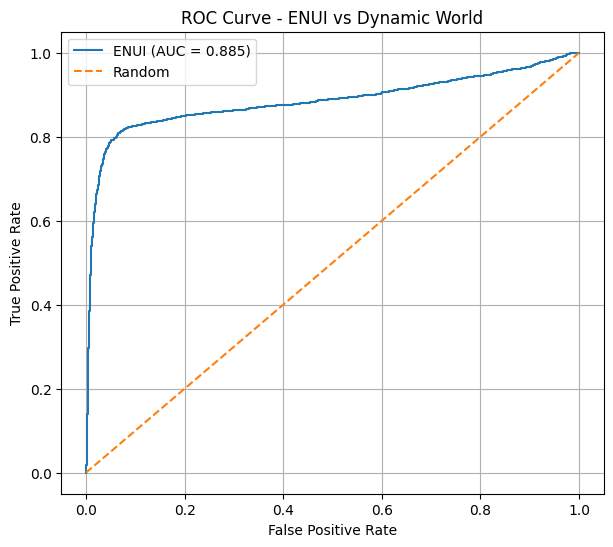

In [30]:
# ==========================================
# ROC Curve
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ENUI (AUC = {auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ENUI vs Dynamic World")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
# ==========================================
# Optimal ENUI Threshold using Youden's J
# ==========================================

import numpy as np

# Youden's J statistic
youden_j = tpr - fpr

# Index of maximum J
optimal_index = np.argmax(youden_j)

# Optimal ENUI threshold
optimal_enui_threshold = thresholds[optimal_index]

# Corresponding TPR and FPR
optimal_tpr = tpr[optimal_index]
optimal_fpr = fpr[optimal_index]

print("====================================")
print("Optimal ENUI Threshold")
print("====================================")

print("Optimal ENUI Threshold:", optimal_enui_threshold)
print("True Positive Rate:", optimal_tpr)
print("False Positive Rate:", optimal_fpr)
print("Youden's J:", youden_j[optimal_index])

Optimal ENUI Threshold
Optimal ENUI Threshold: 0.4697023384931067
True Positive Rate: 0.8072
False Positive Rate: 0.0652
Youden's J: 0.742


In [32]:
# ==========================================
# ENUI Classification & Confusion Matrix
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

# Optimal ENUI threshold
ENUI_THRESHOLD = optimal_enui_threshold

# Convert ENUI to binary classification
enui_predicted = [
    1 if value >= ENUI_THRESHOLD else 0
    for value in enui_values
]

# Reference classification from Dynamic World
dw_reference = dw_values

# Confusion Matrix
cm = confusion_matrix(
    dw_reference,
    enui_predicted
)

# Accuracy metrics
accuracy = accuracy_score(dw_reference, enui_predicted)
precision = precision_score(dw_reference, enui_predicted)
recall = recall_score(dw_reference, enui_predicted)
f1 = f1_score(dw_reference, enui_predicted)
kappa = cohen_kappa_score(dw_reference, enui_predicted)

print("====================================")
print("ENUI Validation Results")
print("====================================")

print("ENUI Threshold:", ENUI_THRESHOLD)

print("\nConfusion Matrix:")
print(cm)

print("\nOverall Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Kappa:", kappa)

ENUI Validation Results
ENUI Threshold: 0.4697023384931067

Confusion Matrix:
[[2337  163]
 [ 482 2018]]

Overall Accuracy: 0.871
Precision: 0.9252636405318662
Recall: 0.8072
F1-score: 0.8622089297158727
Kappa: 0.742


Independent Threshold

In [33]:
# ==========================================
# Independent Validation - Step 1
# Split samples into Train / Validation
# ==========================================

import numpy as np

# Convert to numpy arrays
X = np.array(enui_values)
y = np.array(dw_values)

# Random seed for reproducibility
np.random.seed(42)

# Shuffle indices
indices = np.random.permutation(len(X))

# 70% for threshold selection
split_index = int(0.70 * len(X))

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

# Train / Threshold dataset
X_train = X[train_indices]
y_train = y[train_indices]

# Independent validation dataset
X_val = X[validation_indices]
y_val = y[validation_indices]

print("====================================")
print("Independent Validation Split")
print("====================================")

print("Total samples:", len(X))

print("\nThreshold-selection samples:", len(X_train))
print("  Urban:", np.sum(y_train == 1))
print("  Non-Urban:", np.sum(y_train == 0))

print("\nIndependent validation samples:", len(X_val))
print("  Urban:", np.sum(y_val == 1))
print("  Non-Urban:", np.sum(y_val == 0))

Independent Validation Split
Total samples: 5000

Threshold-selection samples: 3500
  Urban: 1716
  Non-Urban: 1784

Independent validation samples: 1500
  Urban: 784
  Non-Urban: 716


In [34]:
# ==========================================
# Independent Validation - Step 2
# Find ENUI threshold using training samples
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

# ROC using only threshold-selection samples
fpr_train, tpr_train, thresholds_train = roc_curve(
    y_train,
    X_train
)

# AUC on threshold-selection data
auc_train = roc_auc_score(
    y_train,
    X_train
)

# Youden's J
youden_j_train = tpr_train - fpr_train

# Best threshold
optimal_index_train = np.argmax(youden_j_train)

optimal_enui_threshold_train = thresholds_train[optimal_index_train]

optimal_tpr_train = tpr_train[optimal_index_train]
optimal_fpr_train = fpr_train[optimal_index_train]

print("====================================")
print("Threshold Selection Results")
print("====================================")

print("AUC (Threshold-selection data):", auc_train)

print("Optimal ENUI Threshold:",
      optimal_enui_threshold_train)

print("TPR:",
      optimal_tpr_train)

print("FPR:",
      optimal_fpr_train)

print("Youden's J:",
      youden_j_train[optimal_index_train])

Threshold Selection Results
AUC (Threshold-selection data): 0.8863685361723479
Optimal ENUI Threshold: 0.46945168230899637
TPR: 0.8141025641025641
FPR: 0.06390134529147982
Youden's J: 0.7502012188110843


In [35]:
# ==========================================
# Independent Validation - Step 3
# Evaluate ENUI on unseen validation samples
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

# Use ONLY the threshold obtained from the 70% dataset
ENUI_THRESHOLD_FINAL = optimal_enui_threshold_train

# Predict Urban / Non-Urban on independent validation data
y_val_pred = (
    X_val >= ENUI_THRESHOLD_FINAL
).astype(int)

# Confusion Matrix
cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

# Accuracy metrics
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
kappa_val = cohen_kappa_score(y_val, y_val_pred)

print("====================================")
print("INDEPENDENT VALIDATION RESULTS")
print("====================================")

print("ENUI Threshold:", ENUI_THRESHOLD_FINAL)

print("\nConfusion Matrix:")
print(cm_val)

print("\nOverall Accuracy:", accuracy_val)
print("Precision:", precision_val)
print("Recall:", recall_val)
print("F1-score:", f1_val)
print("Kappa:", kappa_val)

INDEPENDENT VALIDATION RESULTS
ENUI Threshold: 0.46945168230899637

Confusion Matrix:
[[665  51]
 [161 623]]

Overall Accuracy: 0.8586666666666667
Precision: 0.9243323442136498
Recall: 0.7946428571428571
F1-score: 0.8545953360768176
Kappa: 0.7186259034055114


In [36]:
# ==========================================
# Independent Validation - Step 4
# Calculate Independent Validation AUC
# ==========================================

from sklearn.metrics import roc_auc_score, roc_curve

# AUC on completely unseen validation samples
auc_val = roc_auc_score(
    y_val,
    X_val
)

# ROC curve for visualization / further analysis
fpr_val, tpr_val, thresholds_val = roc_curve(
    y_val,
    X_val
)

print("====================================")
print("INDEPENDENT VALIDATION AUC")
print("====================================")

print("AUC (Independent Validation):", auc_val)

INDEPENDENT VALIDATION AUC
AUC (Independent Validation): 0.8808449008094859


In [37]:
# ==========================================
# Final ENUI Urban / Non-Urban Map + Legend
# ==========================================

ENUI_THRESHOLD_FINAL = optimal_enui_threshold_train

urban_enui = ENUI.gte(ENUI_THRESHOLD_FINAL).rename("Urban")
nonurban_enui = ENUI.lt(ENUI_THRESHOLD_FINAL).rename("Non_Urban")

print("Final ENUI Threshold:", ENUI_THRESHOLD_FINAL)

Map = geemap.Map()
Map.centerObject(roi, 8)

# ENUI continuous map
Map.addLayer(
    ENUI,
    {
        "min": 0.25,
        "max": 0.75,
        "palette": [
            "#313695",
            "#74add1",
            "#ffffbf",
            "#fdae61",
            "#d73027"
        ]
    },
    "ENUI 2020"
)

# Urban classification
Map.addLayer(
    urban_enui.selfMask(),
    {
        "palette": ["#d73027"]
    },
    "Urban"
)

# Legend
legend_dict = {
    "Urban (ENUI ≥ 0.46945)": "#d73027"
}

Map.add_legend(
    title="ENUI Classification",
    legend_dict=legend_dict
)

Map.add_layer_control()

Map

Final ENUI Threshold: 0.46945168230899637


Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [38]:
# ==========================================
# Random Forest - Step 1
# Split Samples into Training and Validation
# ==========================================

samples_rf = samples.randomColumn(
    columnName="random",
    seed=42
)

# 70% Training
training_samples = samples_rf.filter(
    ee.Filter.lt("random", 0.7)
)

# 30% Validation
validation_samples = samples_rf.filter(
    ee.Filter.gte("random", 0.7)
)

print("====================================")
print("Random Forest Data Split")
print("====================================")

print(
    "Total samples:",
    samples_rf.size().getInfo()
)

print(
    "Training samples:",
    training_samples.size().getInfo()
)

print(
    "Validation samples:",
    validation_samples.size().getInfo()
)

Random Forest Data Split
Total samples: 5000
Training samples: 3511
Validation samples: 1489


In [39]:
# ==========================================
# Random Forest - Step 2
# Train Random Forest Classifier
# ==========================================

rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_samples,
    classProperty="DW_Class",
    inputProperties=["ENUI"]
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [40]:
# ==========================================
# Random Forest - Step 3
# Classify ENUI Image
# ==========================================

rf_classified = (
    ENUI
    .select("ENUI")
    .classify(rf_classifier)
    .rename("RF_Class")
)

print("Random Forest classification completed.")

Random Forest classification completed.


In [41]:
# ==========================================
# Random Forest - Step 4
# Classification Map
# ==========================================

Map_RF = geemap.Map()

Map_RF.centerObject(roi, 8)

Map_RF.addLayer(
    rf_classified.selfMask(),
    {
        "min": 1,
        "max": 1,
        "palette": ["red"]
    },
    "RF Urban"
)

Map_RF.addLayer(
    rf_classified.eq(0).selfMask(),
    {
        "palette": ["gray"]
    },
    "RF Non-Urban"
)

Map_RF.addLayer(
    tehran.style(
        color="white",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province"
)

Map_RF.add_legend(
    title="Random Forest Classification",
    legend_dict={
        "Urban": "red",
        "Non-Urban": "gray"
    }
)

Map_RF.add_layer_control()

Map_RF

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [42]:
# ==========================================
# Random Forest - Step 5
# Independent Validation
# ==========================================

validation_predicted = validation_samples.classify(
    rf_classifier
)

print(
    "Validation samples:",
    validation_predicted.size().getInfo()
)

Validation samples: 1489


In [43]:
# ==========================================
# Random Forest - Step 6
# Confusion Matrix
# ==========================================

rf_confusion_matrix = validation_predicted.errorMatrix(
    "DW_Class",
    "classification"
)

print("====================================")
print("Random Forest Confusion Matrix")
print("====================================")

print(
    rf_confusion_matrix.getInfo()
)

Random Forest Confusion Matrix
[[630, 111], [162, 586]]


In [44]:
# ==========================================
# Random Forest - Step 7
# Accuracy Assessment
# ==========================================

rf_accuracy = rf_confusion_matrix.accuracy()
rf_kappa = rf_confusion_matrix.kappa()

print("====================================")
print("Random Forest Accuracy")
print("====================================")

print(
    "Overall Accuracy:",
    rf_accuracy.getInfo()
)

print(
    "Kappa:",
    rf_kappa.getInfo()
)

Random Forest Accuracy
Overall Accuracy: 0.816655473472129
Kappa: 0.6334208981389549


In [45]:
# ==========================================
# Random Forest - Step 8
# Precision, Recall and F1-score
# ==========================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

y_true_rf = np.array(
    validation_predicted
    .aggregate_array("DW_Class")
    .getInfo()
)

y_pred_rf = np.array(
    validation_predicted
    .aggregate_array("classification")
    .getInfo()
)

rf_precision = precision_score(
    y_true_rf,
    y_pred_rf
)

rf_recall = recall_score(
    y_true_rf,
    y_pred_rf
)

rf_f1 = f1_score(
    y_true_rf,
    y_pred_rf
)

print("====================================")
print("Random Forest Classification Metrics")
print("====================================")

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Random Forest Classification Metrics
Precision: 0.8407460545193687
Recall: 0.7834224598930482
F1-score: 0.8110726643598616


In [46]:
# ==========================================
# Random Forest - Classification Map
# ==========================================

Map_RF = geemap.Map(basemap="SATELLITE")

Map_RF.centerObject(roi, 8)

# Urban
Map_RF.addLayer(
    rf_classified.eq(1).selfMask(),
    {
        "palette": ["red"]
    },
    "Urban"
)

# Non-Urban
Map_RF.addLayer(
    rf_classified.eq(0).selfMask(),
    {
        "palette": ["gray"]
    },
    "Non-Urban"
)

# Tehran Province boundary
Map_RF.addLayer(
    tehran.style(
        color="white",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province"
)

# Legend
Map_RF.add_legend(
    title="Random Forest Classification",
    legend_dict={
        "Urban": "red",
        "Non-Urban": "gray"
    }
)

Map_RF.add_layer_control()

Map_RF

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [47]:
# ==========================================
# Random Forest - Urban / Non-Urban Area
# ==========================================

rf_urban = rf_classified.eq(1)
rf_nonurban = rf_classified.eq(0)

urban_area_rf = (
    ee.Image.pixelArea()
    .updateMask(rf_urban)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=30,
        maxPixels=1e10
    )
    .get("area")
)

nonurban_area_rf = (
    ee.Image.pixelArea()
    .updateMask(rf_nonurban)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=30,
        maxPixels=1e10
    )
    .get("area")
)

urban_km2_rf = ee.Number(urban_area_rf).divide(1e6)
nonurban_km2_rf = ee.Number(nonurban_area_rf).divide(1e6)

total_area_rf = urban_km2_rf.add(nonurban_km2_rf)

urban_percent_rf = (
    urban_km2_rf
    .divide(total_area_rf)
    .multiply(100)
)

nonurban_percent_rf = (
    nonurban_km2_rf
    .divide(total_area_rf)
    .multiply(100)
)

print("====================================")
print("Random Forest Area Statistics")
print("====================================")

print(
    "Urban area (km²):",
    urban_km2_rf.getInfo()
)

print(
    "Non-Urban area (km²):",
    nonurban_km2_rf.getInfo()
)

print(
    "Urban percentage:",
    urban_percent_rf.getInfo()
)

print(
    "Non-Urban percentage:",
    nonurban_percent_rf.getInfo()
)

Random Forest Area Statistics
Urban area (km²): 2886.8906870768014
Non-Urban area (km²): 10811.596170041834
Urban percentage: 21.074522443160088
Non-Urban percentage: 78.92547755683992


idea

In [48]:
# ==========================================
# Random Forest - Complete Accuracy Assessment
# ==========================================

cm = np.array(
    rf_confusion_matrix.getInfo()
)

print("====================================")
print("Confusion Matrix")
print("====================================")
print(cm)


# ------------------------------------------
# Class 0 = Non-Urban
# Class 1 = Urban
# ------------------------------------------

# Producer's Accuracy (PA)
# PA = correctly classified / reference total

pa_nonurban = cm[0, 0] / cm[0, :].sum()
pa_urban = cm[1, 1] / cm[1, :].sum()


# User's Accuracy (UA)
# UA = correctly classified / classified total

ua_nonurban = cm[0, 0] / cm[:, 0].sum()
ua_urban = cm[1, 1] / cm[:, 1].sum()


# F-score
def f1_from_pa_ua(pa, ua):
    return 2 * (pa * ua) / (pa + ua)


f1_nonurban = f1_from_pa_ua(
    pa_nonurban,
    ua_nonurban
)

f1_urban = f1_from_pa_ua(
    pa_urban,
    ua_urban
)


print("\n====================================")
print("Random Forest - Class-wise Accuracy")
print("====================================")

print("\nNon-Urban:")
print("Producer's Accuracy (PA):", pa_nonurban)
print("User's Accuracy (UA):", ua_nonurban)
print("F-score:", f1_nonurban)

print("\nUrban:")
print("Producer's Accuracy (PA):", pa_urban)
print("User's Accuracy (UA):", ua_urban)
print("F-score:", f1_urban)

Confusion Matrix
[[630 111]
 [162 586]]

Random Forest - Class-wise Accuracy

Non-Urban:
Producer's Accuracy (PA): 0.8502024291497976
User's Accuracy (UA): 0.7954545454545454
F-score: 0.821917808219178

Urban:
Producer's Accuracy (PA): 0.7834224598930482
User's Accuracy (UA): 0.8407460545193687
F-score: 0.8110726643598616


In [49]:
# ==========================================
# Random Forest - MICE
# ==========================================

cm = np.array(rf_confusion_matrix.getInfo())

# Total number of validation samples
n = cm.sum()

# Observed agreement
observed_agreement = np.trace(cm) / n

# Expected agreement
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)

expected_agreement = np.sum(
    (row_totals * col_totals) / (n ** 2)
)

# MICE
mice = (
    (observed_agreement - expected_agreement)
    / (1 - expected_agreement)
)

print("====================================")
print("Random Forest - MICE")
print("====================================")
print("MICE:", mice)
print("MICE (%):", mice * 100)

Random Forest - MICE
MICE: 0.6334208981389549
MICE (%): 63.342089813895484


In [50]:
# ==========================================
# SVM Classification using ENUI
# ==========================================

svm_classifier = ee.Classifier.libsvm(
    kernelType="RBF",
    gamma=0.5,
    cost=10
).train(
    features=training_samples,
    classProperty="DW_Class",
    inputProperties=["ENUI"]
)

print("SVM classifier trained successfully.")

SVM classifier trained successfully.


In [51]:
# ==========================================
# SVM Classification of Tehran Province
# ==========================================

svm_classified = (
    ENUI.select("ENUI")
    .classify(svm_classifier)
    .rename("SVM_Class")
)

print("SVM classification completed successfully.")

SVM classification completed successfully.


In [52]:
# ==========================================
# SVM - Validation and Confusion Matrix
# ==========================================

validation_predicted_svm = validation_samples.classify(svm_classifier)

svm_confusion_matrix = validation_predicted_svm.errorMatrix(
    "DW_Class",
    "classification"
)

print("====================================")
print("SVM Confusion Matrix")
print("====================================")
print(svm_confusion_matrix.getInfo())

# Overall Accuracy
svm_accuracy = svm_confusion_matrix.accuracy()

# Kappa / MICE
svm_kappa = svm_confusion_matrix.kappa()

print("\n====================================")
print("SVM Overall Accuracy")
print("====================================")
print("OA:", svm_accuracy.getInfo())
print("MICE / Kappa:", svm_kappa.getInfo())

SVM Confusion Matrix
[[721, 20], [199, 549]]

SVM Overall Accuracy
OA: 0.8529214237743452
MICE / Kappa: 0.7061684698622892


In [53]:
# ==========================================
# SVM - Class-wise Accuracy Assessment
# ==========================================

cm_svm = np.array(svm_confusion_matrix.getInfo())

# ------------------------------------------
# Non-Urban (Class 0)
# ------------------------------------------

nonurban_pa_svm = cm_svm[0,0] / cm_svm[0,:].sum()
nonurban_ua_svm = cm_svm[0,0] / cm_svm[:,0].sum()

nonurban_f1_svm = (
    2 * nonurban_pa_svm * nonurban_ua_svm
    / (nonurban_pa_svm + nonurban_ua_svm)
)

# ------------------------------------------
# Urban (Class 1)
# ------------------------------------------

urban_pa_svm = cm_svm[1,1] / cm_svm[1,:].sum()
urban_ua_svm = cm_svm[1,1] / cm_svm[:,1].sum()

urban_f1_svm = (
    2 * urban_pa_svm * urban_ua_svm
    / (urban_pa_svm + urban_ua_svm)
)

# ------------------------------------------
# Print results
# ------------------------------------------

print("====================================")
print("SVM Class-wise Accuracy")
print("====================================")

print("\nNon-Urban:")
print("PA:", nonurban_pa_svm)
print("UA:", nonurban_ua_svm)
print("F-score:", nonurban_f1_svm)

print("\nUrban:")
print("PA:", urban_pa_svm)
print("UA:", urban_ua_svm)
print("F-score:", urban_f1_svm)

SVM Class-wise Accuracy

Non-Urban:
PA: 0.9730094466936572
UA: 0.783695652173913
F-score: 0.868151715833835

Urban:
PA: 0.733957219251337
UA: 0.9648506151142355
F-score: 0.8337129840546696


In [54]:
# ==========================================
# SVM Classification Map
# ==========================================

Map_SVM = geemap.Map(basemap="SATELLITE")

Map_SVM.centerObject(roi, 8)

Map_SVM.addLayer(
    svm_classified.eq(1).selfMask(),
    {"palette": ["red"]},
    "Urban"
)

Map_SVM.addLayer(
    svm_classified.eq(0).selfMask(),
    {"palette": ["gray"]},
    "Non-Urban"
)

Map_SVM.addLayer(
    tehran.style(
        color="white",
        fillColor="00000000",
        width=1
    ),
    {},
    "Tehran Province"
)

Map_SVM.add_legend(
    title="SVM Classification",
    legend_dict={
        "Urban": "red",
        "Non-Urban": "gray"
    }
)

Map_SVM.add_layer_control()

Map_SVM

Map(center=[35.55369520463797, 51.72714652707821], controls=(WidgetControl(options=['position', 'transparent_b…

In [55]:
# ==========================================
# SVM - Urban / Non-Urban Area
# ==========================================

svm_urban = svm_classified.eq(1)
svm_nonurban = svm_classified.eq(0)

# Pixel area in km²
pixel_area = ee.Image.pixelArea().divide(1e6)

# Urban area
svm_urban_area = (
    pixel_area
    .updateMask(svm_urban)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=500,
        maxPixels=1e9
    )
)

# Non-Urban area
svm_nonurban_area = (
    pixel_area
    .updateMask(svm_nonurban)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=500,
        maxPixels=1e9
    )
)

urban_area_svm = svm_urban_area.get("area").getInfo()
nonurban_area_svm = svm_nonurban_area.get("area").getInfo()

total_area_svm = urban_area_svm + nonurban_area_svm

urban_percent_svm = (urban_area_svm / total_area_svm) * 100
nonurban_percent_svm = (nonurban_area_svm / total_area_svm) * 100

print("====================================")
print("SVM Area Statistics")
print("====================================")

print("Urban area:", urban_area_svm, "km²")
print("Non-Urban area:", nonurban_area_svm, "km²")

print("\nUrban percentage:", urban_percent_svm, "%")
print("Non-Urban percentage:", nonurban_percent_svm, "%")

print("\nTotal classified area:", total_area_svm, "km²")

SVM Area Statistics
Urban area: 1228.9260622258432 km²
Non-Urban area: 12469.23103371533 km²

Urban percentage: 8.971470057019419 %
Non-Urban percentage: 91.02852994298058 %

Total classified area: 13698.157095941173 km²
